# Data Loading

In [58]:
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
df_employee_survey_data = pd.read_csv(Path("data/raw/employee_survey_data.csv"))
df_general_data = pd.read_csv(Path("data/raw/general_data.csv"))
df_in_time = pd.read_csv(Path("data/raw/in_time.csv"))
df_out_time = pd.read_csv(Path("data/raw/out_time.csv"))
df_manager_survey_data = pd.read_csv(Path("data/raw/manager_survey_data.csv"))

In [27]:
df = df_general_data.merge(df_employee_survey_data, on="EmployeeID") \
                    .merge(df_manager_survey_data, on="EmployeeID")

print(f"Shape: {df.shape}")
df.head()

Shape: (4410, 29)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,9.0,2,6,0,4,4.0,1.0,3.0,3,3


# Data View

In [ ]:
df.head()

In [ ]:
df.describe(include='all')

In [ ]:
df.info()

# Data Cleaning

## Remove missing values 

In [28]:
import missingno as msno

In [29]:
def replace_missing_values(df):
    for column in df.columns:
        if df[column].dtype in ['object', 'string']:
            df[column] = df[column].fillna(df[column].mode()[0])
        else:
            df[column] = df[column].fillna(df[column].median())
    return df

In [30]:
df = replace_missing_values(df)
df_out_time = replace_missing_values(df_out_time)
df_in_time = replace_missing_values(df_in_time)

c:\Users\sokhn\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\sokhn\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\sokhn\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\sokhn\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\sokhn\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out,

## Check for duplicates

In [31]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Total rows: {len(df)}")

Duplicate rows: 0
Total rows: 4410


## Remove useless columns

In [33]:
num_yes = df['Over18'].value_counts().get('Y', 0)
print(f"Number of 'Yes' in 'Over18': {num_yes}")

num_no = df['Over18'].value_counts().get('N', 0)
print(f"Number of 'No' in 'Over18': {num_no}")

num_yes = df['EmployeeCount'].value_counts().get(1, 0)
print(f"Number of 'Yes' in 'EmployeeCount': {num_yes}")

num_no = df['EmployeeCount'].value_counts().get(0, 0)
print(f"Number of 'No' in 'EmployeeCount': {num_no}")

num_eight = df['StandardHours'].value_counts().get(8, 0)
print(f"Number of '8' in 'StandardHours': {num_eight}")

num_zero = df['StandardHours'].value_counts().get(0, 0)
print(f"Number of '0' in 'StandardHours': {num_zero}")


Number of 'Yes' in 'Over18': 4410
Number of 'No' in 'Over18': 0
Number of 'Yes' in 'EmployeeCount': 4410
Number of 'No' in 'EmployeeCount': 0
Number of '8' in 'StandardHours': 4410
Number of '0' in 'StandardHours': 0


Observation : we can see that “Over 18” and "EmployeeCount" columns contain only “Yes” entries, so we can delete them since they serve no purpose. Same for StandardHours with the value 8

In [34]:
df = df.drop(columns=['Over18', 'EmployeeCount', 'StandardHours'])

## Detect Outliers

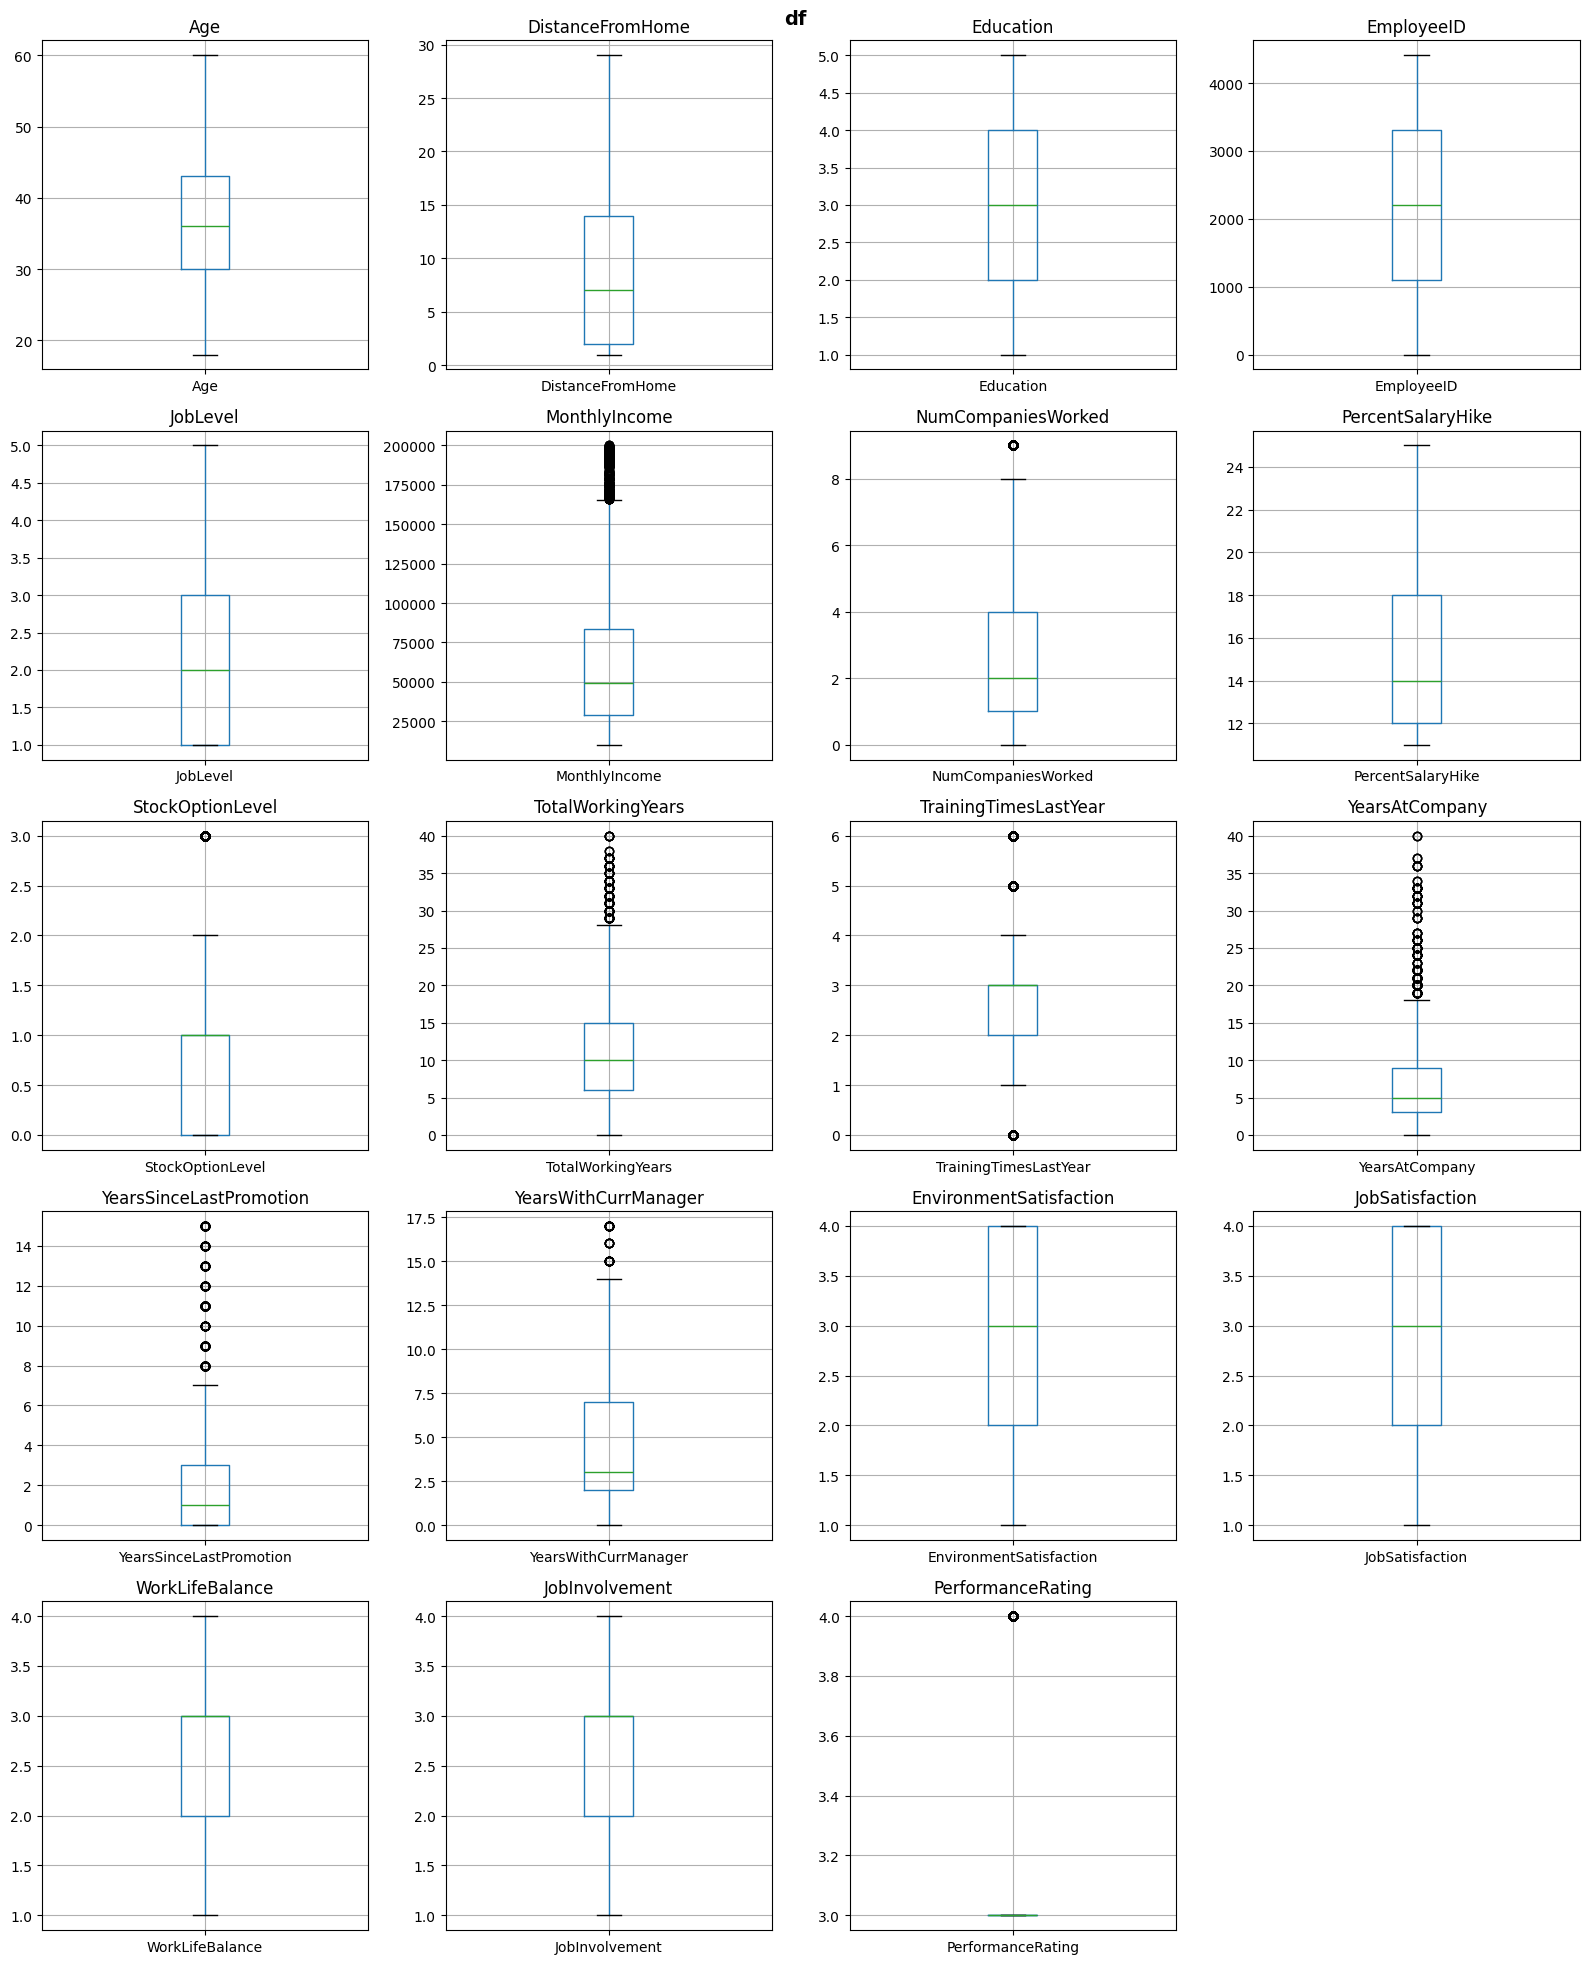

In [35]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()
for i, column in enumerate(num_cols):
    df.boxplot(column=[column], ax=axes[i])
    axes[i].set_title(column)
for i in range(n, len(axes)):
    axes[i].set_visible(False)
fig.suptitle("df", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [36]:
cat_cols = df.select_dtypes(exclude="number").columns
for column in cat_cols:
    print(f"--- {column} ---")
    print(df[column].value_counts())
    print()

--- Attrition ---
Attrition
No     3699
Yes     711
Name: count, dtype: int64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        3129
Travel_Frequently     831
Non-Travel            450
Name: count, dtype: int64

--- Department ---
Department
Research & Development    2883
Sales                     1338
Human Resources            189
Name: count, dtype: int64

--- EducationField ---
EducationField
Life Sciences       1818
Medical             1392
Marketing            477
Technical Degree     396
Other                246
Human Resources       81
Name: count, dtype: int64

--- Gender ---
Gender
Male      2646
Female    1764
Name: count, dtype: int64

--- JobRole ---
JobRole
Sales Executive              978
Research Scientist           876
Laboratory Technician        777
Manufacturing Director       435
Healthcare Representative    393
Manager                      306
Sales Representative         249
Research Director            240
Human Resources              156
Name: count, 

In [37]:
def detect_outliers(dataframe):
    for column in dataframe.select_dtypes(include="number").columns:
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        outliers = dataframe[(dataframe[column] < Q1 - 1.5 * IQR) | (dataframe[column] > Q3 + 1.5 * IQR)]
        if len(outliers) > 0:
            print(f"{column}: {len(outliers)} outliers (min={dataframe[column].min()}, max={dataframe[column].max()})")

detect_outliers(df)

MonthlyIncome: 342 outliers (min=10090, max=199990)
NumCompaniesWorked: 156 outliers (min=0.0, max=9.0)
StockOptionLevel: 255 outliers (min=0, max=3)
TotalWorkingYears: 189 outliers (min=0.0, max=40.0)
TrainingTimesLastYear: 714 outliers (min=0, max=6)
YearsAtCompany: 312 outliers (min=0, max=40)
YearsSinceLastPromotion: 321 outliers (min=0, max=15)
YearsWithCurrManager: 42 outliers (min=0, max=17)
PerformanceRating: 678 outliers (min=3, max=4)


## Feature Engineering (in_time / out_time)

In [38]:
# Convert timestamp columns to datetime
date_cols = [col for col in df_in_time.columns if col != "Unnamed: 0"]

for col in date_cols:
    df_in_time[col] = pd.to_datetime(df_in_time[col], errors="coerce")
    df_out_time[col] = pd.to_datetime(df_out_time[col], errors="coerce")

# Compute work duration in hours for each day
df_duration = df_out_time[date_cols] - df_in_time[date_cols]
df_duration = df_duration.apply(lambda x: x.dt.total_seconds() / 3600)

df_duration.head()

,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,2015-01-14,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,NaN,7.208333,7.189722,7.410833,7.006667,7.289722,7.484444,7.262778,7.831111,NaN,...,6.900000,7.339167,7.395833,6.504722,7.596389,NaN,7.773889,7.315000,7.778889,7.080278
1,NaN,8.109167,7.454722,6.697222,7.396944,7.416667,7.150833,7.611389,7.278889,NaN,...,7.903056,7.753889,7.712222,7.435556,5.978889,NaN,7.614722,7.982500,7.986111,8.227222
2,NaN,6.692500,7.265556,6.405278,6.765000,7.345000,6.861389,7.418611,6.999722,NaN,...,6.785833,7.163611,6.801667,6.730278,6.849722,NaN,7.023889,7.438889,7.538889,6.786389
3,NaN,7.338333,7.291944,6.943056,6.919444,6.850833,7.193056,6.998611,7.306389,NaN,...,7.629167,6.846667,7.326389,7.413611,7.085000,NaN,7.447222,7.416667,7.366389,7.133056
4,NaN,8.055556,7.988056,7.682500,7.806111,7.662222,7.721667,8.365000,8.257222,NaN,...,7.903611,7.665000,7.957500,7.786944,8.249444,NaN,7.662222,8.268611,7.953333,8.018056


In [39]:
# Extract features per employee
df_time_features = pd.DataFrame()
df_time_features["EmployeeID"] = df_in_time["Unnamed: 0"]

# Average work duration (hours/day)
df_time_features["AvgWorkHours"] = df_duration.mean(axis=1)

# Std deviation of work duration (regularity)
df_time_features["StdWorkHours"] = df_duration.std(axis=1)

# Number of absent days (NaT in in_time = absent)
df_time_features["AbsentDays"] = df_in_time[date_cols].isna().sum(axis=1)

# Average arrival hour
df_arrival = df_in_time[date_cols].apply(lambda x: x.dt.hour + x.dt.minute / 60)
df_time_features["AvgArrivalHour"] = df_arrival.mean(axis=1)

# Average departure hour
df_departure = df_out_time[date_cols].apply(lambda x: x.dt.hour + x.dt.minute / 60)
df_time_features["AvgDepartureHour"] = df_departure.mean(axis=1)

df_time_features.head()

,EmployeeID,AvgWorkHours,StdWorkHours,AbsentDays,AvgArrivalHour,AvgDepartureHour
0,1,7.332589,0.345296,12,9.990897,17.323762
1,2,7.673562,0.377188,12,9.977711,17.650000
2,3,7.009591,0.326156,12,10.012784,17.022624
3,4,7.184439,0.311909,12,9.970950,17.155154
4,5,7.989560,0.335775,12,9.988956,17.978581


In [40]:
# Merge time features into df (same row order, drop EmployeeID helper column)
df = pd.concat([df, df_time_features.drop(columns=["EmployeeID"])], axis=1)

print(f"Shape after merge: {df.shape}")
df[["AvgWorkHours", "StdWorkHours", "AbsentDays", "AvgArrivalHour", "AvgDepartureHour"]].describe()

Shape after merge: (4410, 31)


,AvgWorkHours,StdWorkHours,AbsentDays,AvgArrivalHour,AvgDepartureHour
count,4410.000000,4410.000000,4410.0,4410.000000,4410.000000
mean,7.660595,0.424194,12.0,9.988780,17.649339
std,1.283256,0.165437,0.0,0.017317,1.283760
min,5.983206,0.262225,12.0,9.927309,15.966934
25%,6.676053,0.325579,12.0,9.977376,16.660007
50%,7.373362,0.355332,12.0,9.989023,17.361044
75%,8.269605,0.442777,12.0,10.000067,18.257898
max,10.995263,1.190621,12.0,10.062584,21.001941


## Standardize and quantify 

### Standardize

In [41]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = [
    "Age", "DistanceFromHome", "MonthlyIncome", "NumCompaniesWorked",
    "PercentSalaryHike", "TotalWorkingYears", "TrainingTimesLastYear",
    "YearsAtCompany", "YearsSinceLastPromotion", "YearsWithCurrManager",
    "AvgWorkHours", "StdWorkHours", "AbsentDays", "AvgArrivalHour", "AvgDepartureHour"
]

print(f"Columns to standardize: {cols_to_scale}")

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.head()

Columns to standardize: ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AvgWorkHours', 'StdWorkHours', 'AbsentDays', 'AvgArrivalHour', 'AvgDepartureHour']


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,AvgWorkHours,StdWorkHours,AbsentDays,AvgArrivalHour,AvgDepartureHour
0,1.541369,No,Travel_Rarely,Sales,-0.393938,2,Life Sciences,1,Female,1,...,3.0,4.0,2.0,3,3,-0.255634,-0.476964,0.0,0.122279,-0.253641
1,-0.648668,Yes,Travel_Frequently,Research & Development,0.099639,1,Life Sciences,2,Female,1,...,3.0,2.0,4.0,2,4,0.010106,-0.284166,0.0,-0.639280,0.000515
2,-0.539166,No,Travel_Frequently,Research & Development,0.963398,4,Other,3,Male,4,...,2.0,2.0,1.0,3,3,-0.507365,-0.592669,0.0,1.386388,-0.488243
3,0.117845,No,Non-Travel,Research & Development,-0.887515,5,Life Sciences,4,Male,3,...,4.0,4.0,3.0,2,3,-0.371096,-0.678795,0.0,-1.029723,-0.384995
4,-0.539166,No,Travel_Rarely,Research & Development,0.099639,1,Medical,5,Male,1,...,4.0,1.0,3.0,3,3,0.256381,-0.534517,0.0,0.010171,0.256496


### Quantify

In [42]:
for col in df.select_dtypes(exclude="number").columns:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")

Attrition: 2 unique values -> ['No' 'Yes']
BusinessTravel: 3 unique values -> ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: 3 unique values -> ['Sales' 'Research & Development' 'Human Resources']
EducationField: 6 unique values -> ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: 2 unique values -> ['Female' 'Male']
JobRole: 9 unique values -> ['Healthcare Representative' 'Research Scientist' 'Sales Executive'
 'Human Resources' 'Research Director' 'Laboratory Technician'
 'Manufacturing Director' 'Sales Representative' 'Manager']
MaritalStatus: 3 unique values -> ['Married' 'Single' 'Divorced']


In [43]:
# Label encoding for binary columns
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

# Ordinal encoding for BusinessTravel (ordered)
travel_order = {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
df["BusinessTravel"] = df["BusinessTravel"].map(travel_order)

# One-hot encoding for nominal columns (no inherent order)
df = pd.get_dummies(df, columns=["Department", "EducationField", "JobRole", "MaritalStatus"], dtype=int)

df.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,EmployeeID,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1.541369,0,1,-0.393938,2,1,0,1,1.405136,-0.678464,...,0,0,0,0,0,0,0,0,1,0
1,-0.648668,1,2,0.099639,1,2,0,1,-0.491661,-1.079486,...,0,0,0,0,1,0,0,0,0,1
2,-0.539166,0,2,0.963398,4,3,1,4,2.725053,-0.678464,...,0,0,0,0,0,1,0,0,1,0
3,0.117845,0,0,-0.887515,5,4,1,3,0.386301,0.123580,...,0,0,0,0,0,0,0,0,1,0
4,-0.539166,0,1,0.099639,1,5,1,1,-0.884109,0.524602,...,0,0,0,0,0,1,0,0,0,1


### Encoding Summary

**Label Encoding (binary):**
| Column | 0 | 1 |
|--------|---|---|
| Attrition | No | Yes |
| Gender | Female | Male |

**Ordinal Encoding (ordered):**
| Column | 0 | 1 | 2 |
|--------|---|---|---|
| BusinessTravel | Non-Travel | Travel_Rarely | Travel_Frequently |

**One-Hot Encoding (nominal):**
- **Department** → `Department_Human Resources`, `Department_Research & Development`, `Department_Sales`
- **EducationField** → `EducationField_Human Resources`, `EducationField_Life Sciences`, `EducationField_Marketing`, `EducationField_Medical`, `EducationField_Other`, `EducationField_Technical Degree`
- **JobRole** → `JobRole_Healthcare Representative`, `JobRole_Human Resources`, `JobRole_Laboratory Technician`, `JobRole_Manager`, `JobRole_Manufacturing Director`, `JobRole_Research Director`, `JobRole_Research Scientist`, `JobRole_Sales Executive`, `JobRole_Sales Representative`
- **MaritalStatus** → `MaritalStatus_Divorced`, `MaritalStatus_Married`, `MaritalStatus_Single`

# Exploratory Data Analysis (EDA)

## Target Distribution

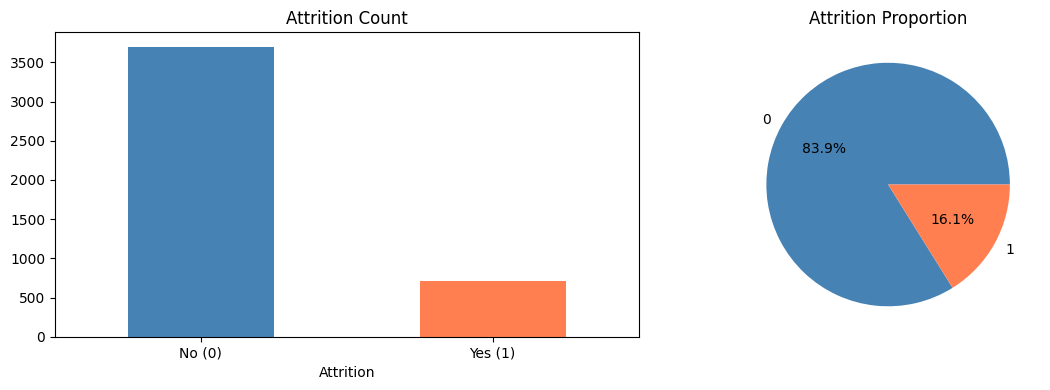

Class balance: {0: 3699, 1: 711}


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Attrition"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Attrition Count")
axes[0].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

df["Attrition"].value_counts(normalize=True).plot(kind="pie", ax=axes[1], autopct="%.1f%%", colors=["steelblue", "coral"])
axes[1].set_title("Attrition Proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"Class balance: {df['Attrition'].value_counts().to_dict()}")

## Correlation Matrix

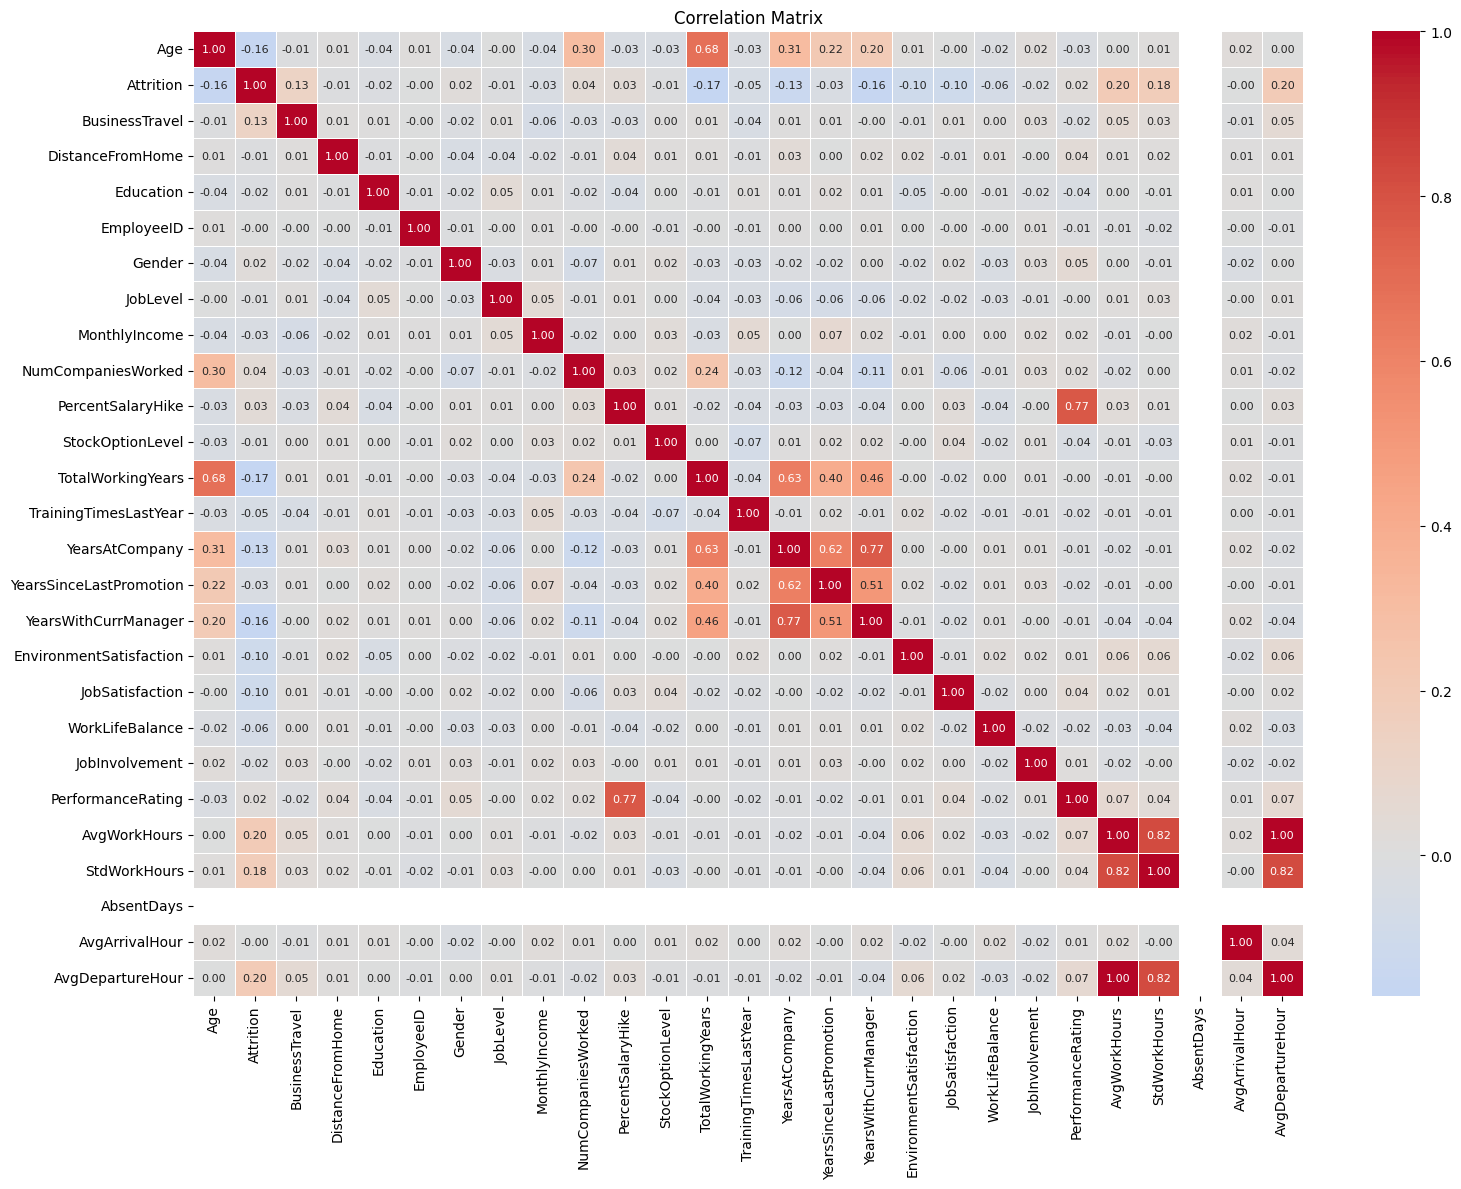

In [45]:
# Exclude one-hot encoded columns from correlation matrix
one_hot_prefixes = ("Department_", "EducationField_", "JobRole_", "MaritalStatus_")
cols_corr = [col for col in df.select_dtypes(include="number").columns if not col.startswith(one_hot_prefixes)]

plt.figure(figsize=(16, 12))
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Top Correlations with Attrition

AvgWorkHours               0.201191
AvgDepartureHour           0.201097
StdWorkHours               0.183267
TotalWorkingYears         -0.170162
Age                       -0.159205
YearsWithCurrManager      -0.156199
YearsAtCompany            -0.134392
BusinessTravel             0.127006
JobSatisfaction           -0.103068
EnvironmentSatisfaction   -0.101625
WorkLifeBalance           -0.062975
TrainingTimesLastYear     -0.049431
NumCompaniesWorked         0.042064
YearsSinceLastPromotion   -0.033019
PercentSalaryHike          0.032533
Name: Attrition, dtype: float64


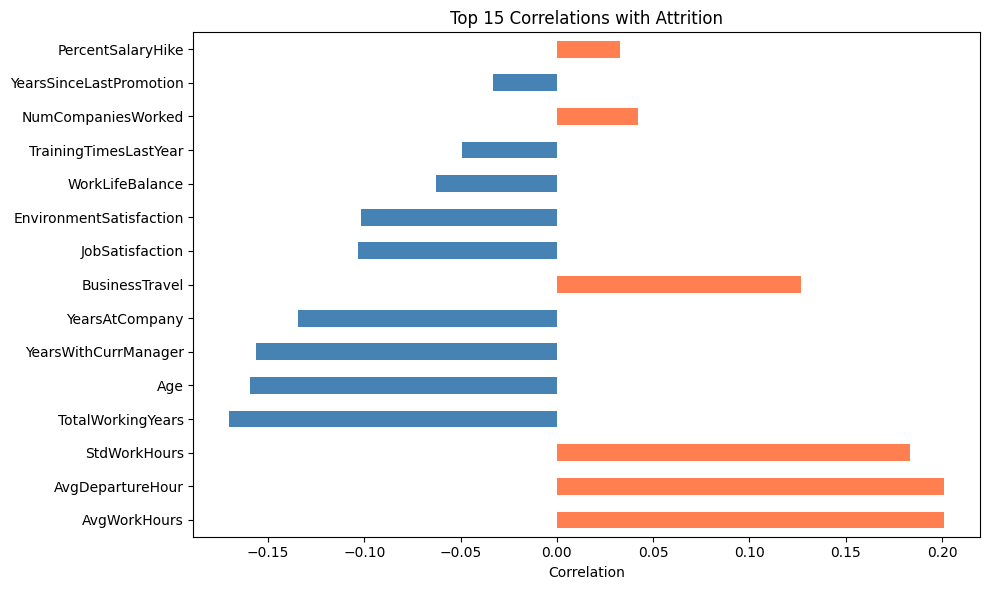

In [46]:
attrition_corr = corr["Attrition"].drop("Attrition").sort_values(key=abs, ascending=False)
print(attrition_corr.head(15))

plt.figure(figsize=(10, 6))
attrition_corr.head(15).plot(kind="barh", color=["coral" if x > 0 else "steelblue" for x in attrition_corr.head(15)])
plt.title("Top 15 Correlations with Attrition")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

## Key Feature Distributions by Attrition

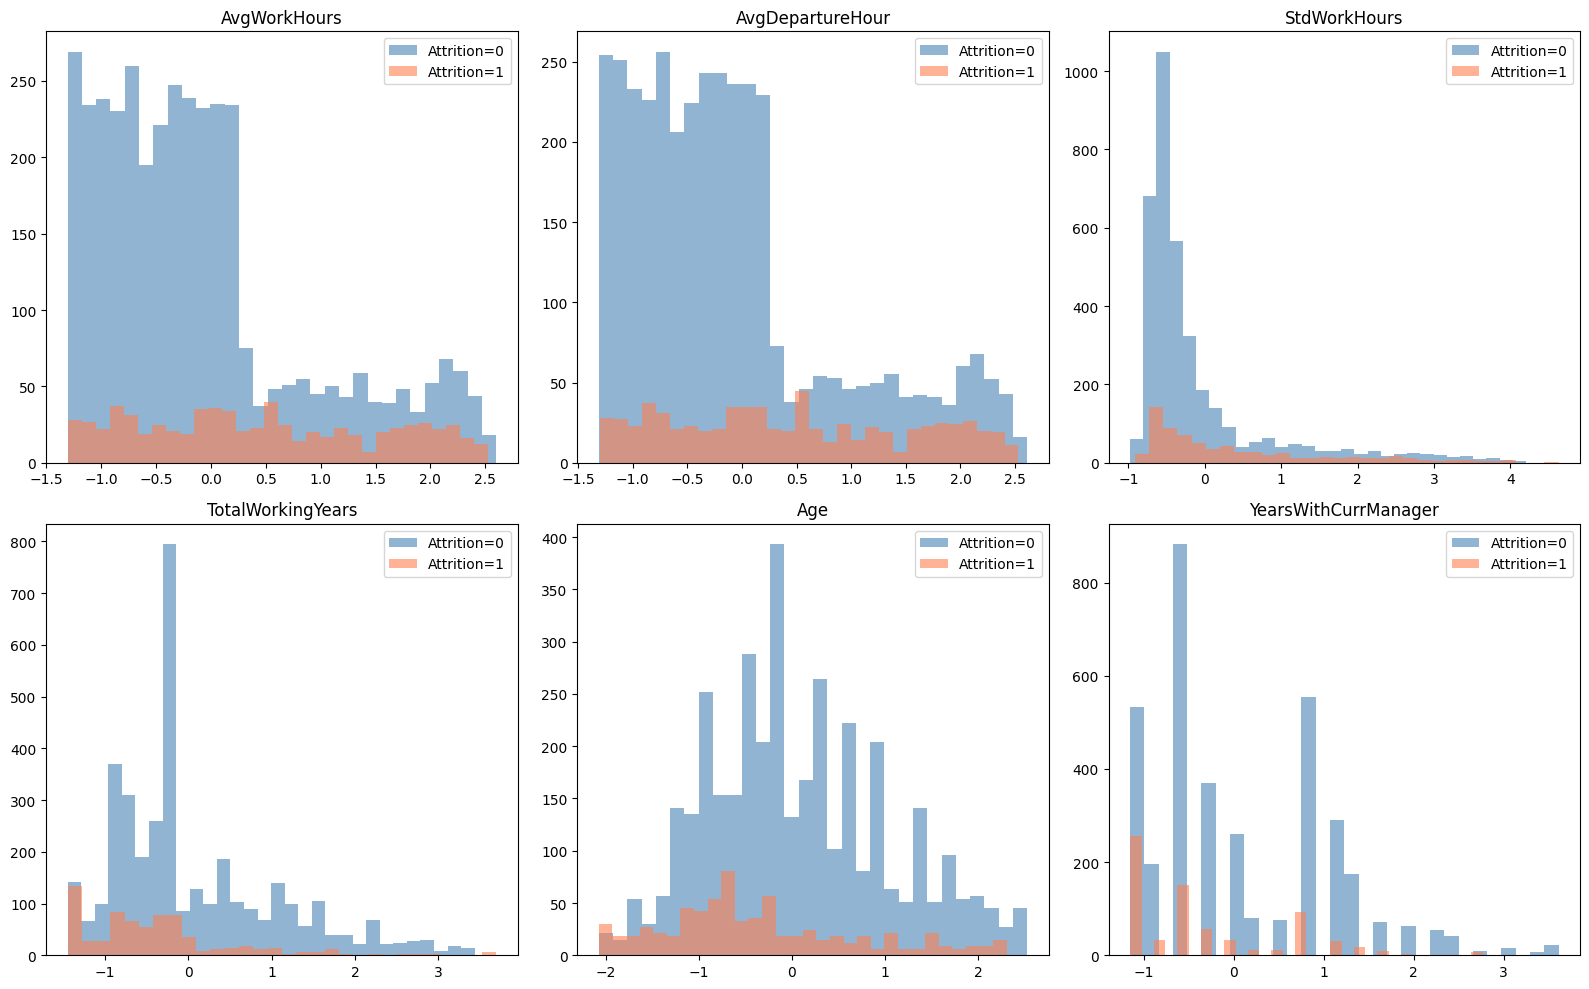

In [47]:
top_features = attrition_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    for label, color in [(0, "steelblue"), (1, "coral")]:
        axes[i].hist(df[df["Attrition"] == label][feature], bins=30, alpha=0.6, label=f"Attrition={label}", color=color)
    axes[i].set_title(feature)
    axes[i].legend()

plt.tight_layout()
plt.show()

## 3. Préparation des données pour le ML

### 3.1 Séparation X / y et gestion du déséquilibre de classes

Notre target est **déséquilibrée** (~84% No / ~16% Yes). Nous utilisons deux approches complémentaires :
- `class_weight='balanced'` dans les modèles → pondère automatiquement les classes
- `stratify=y` dans le split → garantit que les deux splits ont la même proportion d'attrition

In [49]:
# Imports for modeling
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')


In [50]:
# ─── Séparation X / y ─────────────────────────────────────────────────────────
TARGET = "Attrition"
# On retire l'ID si présent
id_cols = [c for c in df.columns if "EmployeeID" in c]

X = df.drop(columns=[TARGET] + id_cols)
y = df[TARGET]

print(f"Features : {X.shape[1]} colonnes | Observations : {X.shape[0]} lignes")

# ─── Train / Test split stratifié ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Garantit les mêmes proportions dans train et test
)

print(f"\nTrain : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Attrition dans train : {y_train.mean():.1%} | dans test : {y_test.mean():.1%}")

Features : 46 colonnes | Observations : 4410 lignes

Train : 3528 lignes | Test : 882 lignes
Attrition dans train : 16.1% | dans test : 16.1%


## 4. Modèle 1 : Random Forest

**Fonctionnement :** agrégation de N arbres de décision entraînés sur des sous-échantillons aléatoires des données et des features → vote majoritaire final.

**Paramètres clés :**
- `n_estimators` : nombre d'arbres (plus = mieux, mais plus lent)
- `max_depth` : profondeur max de chaque arbre (évite le surapprentissage)
- `class_weight='balanced'` : **crucial** pour notre déséquilibre de classes

In [51]:
# ─── Entraînement ─────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',   # Compense le déséquilibre No/Yes
    random_state=42,
    n_jobs=-1                  # Utilise tous les coeurs CPU
)

rf_model.fit(X_train, y_train)
y_pred_rf    = rf_model.predict(X_test)
y_proba_rf   = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest entraîné ✓")

Random Forest entraîné ✓


#######################################################
       RÉSULTATS — RANDOM FOREST
#######################################################

 Rapport de classification :
              precision    recall  f1-score   support

No Attrition       0.96      0.97      0.97       740
   Attrition       0.83      0.80      0.81       142

    accuracy                           0.94       882
   macro avg       0.90      0.88      0.89       882
weighted avg       0.94      0.94      0.94       882

AUC-ROC  : 0.9748
F1-Score (Attrition) : 0.8129


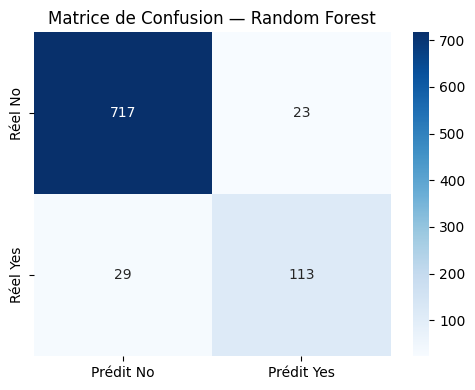

In [68]:
# ─── Évaluation Random Forest ─────────────────────────────────────────────────
print("#"*55)
print("       RÉSULTATS — RANDOM FOREST")
print("#"*55)

print("\n Rapport de classification :")
print(classification_report(y_test, y_pred_rf, target_names=["No Attrition", "Attrition"]))

print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"F1-Score (Attrition) : {f1_score(y_test, y_pred_rf):.4f}")

# ─── Matrice de confusion ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=["Prédit No", "Prédit Yes"],
    yticklabels=["Réel No",   "Réel Yes"]
)
ax.set_title("Matrice de Confusion — Random Forest")
plt.tight_layout()
plt.show()

## 5. Modèle 2 : Gradient Boosting

**Fonctionnement :** construction séquentielle d'arbres où chaque arbre **corrige les erreurs du précédent**. Contrairement au Random Forest (parallèle), le Gradient Boosting est un algorithme itératif d'optimisation du gradient.

**Paramètres clés :**
- `n_estimators` : nombre d'itérations de boosting
- `learning_rate` : taux d'apprentissage — faible = plus robuste mais plus lent
- `max_depth` : profondeur des arbres (typiquement 3-5 pour le boosting)
- `subsample` : fraction des données utilisée à chaque itération (réduction du surapprentissage)

In [69]:
# ─── Calcul du ratio de déséquilibre pour le paramètre scale_pos_weight ───────
# (équivalent de class_weight='balanced' mais propre au Gradient Boosting)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count
print(f"Ratio No/Yes dans le train : {scale_pos:.2f} → utilisé comme scale_pos_weight")

# ─── Entraînement ─────────────────────────────────────────────────────────────
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,     # Petit learning rate = meilleure généralisation
    max_depth=4,
    subsample=0.8,          # 80% des données à chaque arbre → réduction overfitting
    min_samples_leaf=10,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb  = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting entraîné ✓")

Ratio No/Yes dans le train : 5.20 → utilisé comme scale_pos_weight
Gradient Boosting entraîné ✓


       RÉSULTATS — GRADIENT BOOSTING

 Rapport de classification :
              precision    recall  f1-score   support

No Attrition       0.95      1.00      0.98       740
   Attrition       0.99      0.75      0.85       142

    accuracy                           0.96       882
   macro avg       0.97      0.87      0.91       882
weighted avg       0.96      0.96      0.96       882

AUC-ROC  : 0.9814
F1-Score (Attrition) : 0.8514


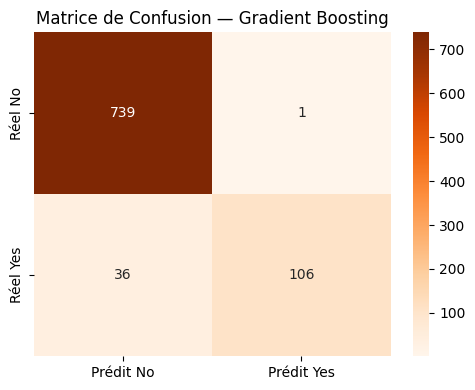

In [70]:
# ─── Évaluation Gradient Boosting ─────────────────────────────────────────────
print("="*55)
print("       RÉSULTATS — GRADIENT BOOSTING")
print("="*55)

print("\n Rapport de classification :")
print(classification_report(y_test, y_pred_gb, target_names=["No Attrition", "Attrition"]))

print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba_gb):.4f}")
print(f"F1-Score (Attrition) : {f1_score(y_test, y_pred_gb):.4f}")

# ─── Matrice de confusion ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(
    cm_gb, annot=True, fmt='d', cmap='Oranges', ax=ax,
    xticklabels=["Prédit No", "Prédit Yes"],
    yticklabels=["Réel No",   "Réel Yes"]
)
ax.set_title("Matrice de Confusion — Gradient Boosting")
plt.tight_layout()
plt.show()

## 6. Comparaison des modèles

### 6.1 Courbes ROC

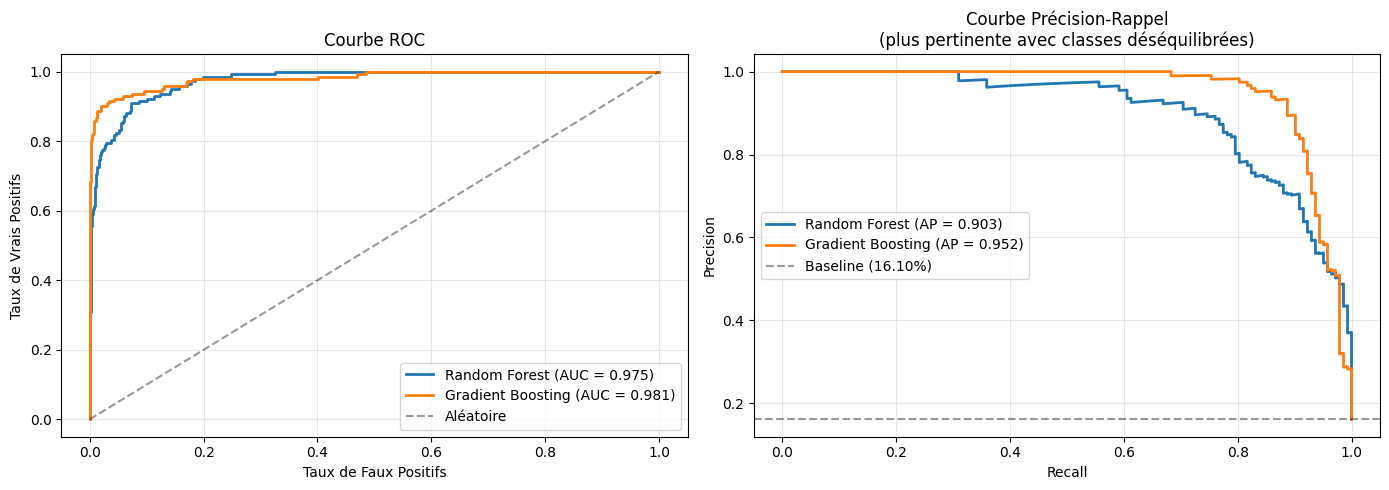

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Courbe ROC ───────────────────────────────────────────────────────────────
ax = axes[0]
for name, y_proba in [("Random Forest", y_proba_rf), ("Gradient Boosting", y_proba_gb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Aléatoire")
ax.set_xlabel("Taux de Faux Positifs")
ax.set_ylabel("Taux de Vrais Positifs")
ax.set_title("Courbe ROC")
ax.legend()
ax.grid(alpha=0.3)

# ─── Courbe Précision-Rappel ──────────────────────────────────────────────────
# Plus informative que ROC en cas de déséquilibre de classes !
ax = axes[1]
for name, y_proba in [("Random Forest", y_proba_rf), ("Gradient Boosting", y_proba_gb)]:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(recall, precision, label=f"{name} (AP = {ap:.3f})", linewidth=2)

baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f"Baseline ({baseline:.2%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Courbe Précision-Rappel\n(plus pertinente avec classes déséquilibrées)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
results = []
for name, y_pred, y_proba in [
    ("Random Forest",     y_pred_rf, y_proba_rf),
    ("Gradient Boosting", y_pred_gb, y_proba_gb),
]:
    results.append({
        "Modèle":     name,
        "Precision":  precision_score(y_test, y_pred),
        "Recall":     recall_score(y_test, y_pred),
        "F1-Score":   f1_score(y_test, y_pred),
        "AUC-ROC":    roc_auc_score(y_test, y_proba),
        "Avg Prec":   average_precision_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Modèle").round(4)
print(results_df.to_string())

                   Precision  Recall  F1-Score  AUC-ROC  Avg Prec
Modèle                                                           
Random Forest         0.8309  0.7958    0.8129   0.9748    0.9026
Gradient Boosting     0.9907  0.7465    0.8514   0.9814    0.9523


In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Validation croisée 5-fold (stratifiée) en cours...\n")

for name, model in [("Random Forest", rf_model), ("Gradient Boosting", gb_model)]:
    scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='roc_auc',   # Métrique la plus pertinente pour un problème déséquilibré
        n_jobs=-1
    )
    print(f"{name}")
    print(f"  AUC-ROC par fold : {np.round(scores, 4)}")
    print(f"  Moyenne : {scores.mean():.4f} ± {scores.std():.4f}")
    print()

Validation croisée 5-fold (stratifiée) en cours...

Random Forest
  AUC-ROC par fold : [0.9814 0.9642 0.9759 0.9749 0.9671]
  Moyenne : 0.9727 ± 0.0063

Gradient Boosting
  AUC-ROC par fold : [0.9798 0.9793 0.9833 0.9873 0.9746]
  Moyenne : 0.9808 ± 0.0042



## 8. Optimisation des hyperparamètres (GridSearch)

On affine les paramètres du meilleur modèle via une recherche sur grille avec validation croisée. **On optimise sur le F1-Score** plutôt que l'accuracy, car l'accuracy est trompeuse avec des classes déséquilibrées.

In [74]:
# ─── GridSearch sur le Random Forest ──────────────────────────────────────────
# (plus rapide que GB pour la démonstration — adapter selon les résultats de la CV)

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth':    [5, 10, None],
    'min_samples_leaf': [3, 5, 10],
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',         # Optimise le F1 sur la classe Attrition=Yes
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"\n✓ Meilleurs paramètres : {grid_search_rf.best_params_}")
print(f"✓ Meilleur F1 en CV    : {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

✓ Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 300}
✓ Meilleur F1 en CV    : 0.8511


In [61]:
# ─── Évaluation du modèle optimisé ────────────────────────────────────────────
best_rf = grid_search_rf.best_estimator_
y_pred_best  = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print("="*55)
print("    RANDOM FOREST OPTIMISÉ (GridSearch)")
print("="*55)
print(classification_report(y_test, y_pred_best, target_names=["No Attrition", "Attrition"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"F1      : {f1_score(y_test, y_pred_best):.4f}")

    RANDOM FOREST OPTIMISÉ (GridSearch)
              precision    recall  f1-score   support

No Attrition       0.97      0.99      0.98       740
   Attrition       0.97      0.85      0.90       142

    accuracy                           0.97       882
   macro avg       0.97      0.92      0.94       882
weighted avg       0.97      0.97      0.97       882

AUC-ROC : 0.9910
F1      : 0.9023


## 9. Importance des features

L'un des grands avantages de ces modèles pour les RH : pouvoir **expliquer** quels facteurs prédisent le mieux l'attrition.

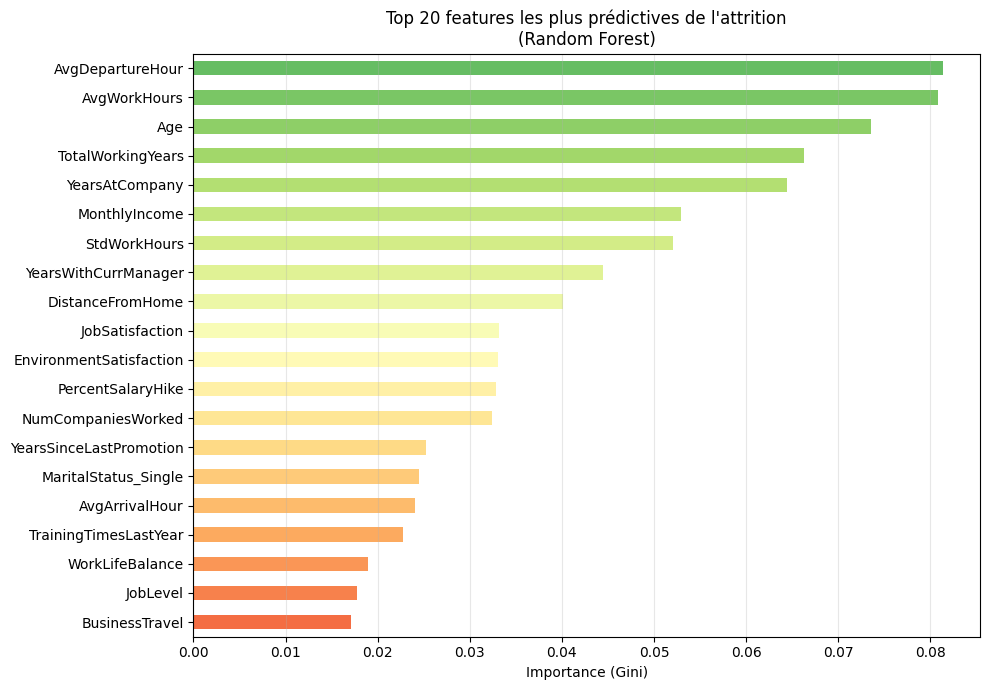


Top 10 features :
AvgDepartureHour        0.0813
AvgWorkHours            0.0808
Age                     0.0735
TotalWorkingYears       0.0663
YearsAtCompany          0.0645
MonthlyIncome           0.0529
StdWorkHours            0.0521
YearsWithCurrManager    0.0445
DistanceFromHome        0.0401
JobSatisfaction         0.0332


In [62]:
# ─── Feature importance — Random Forest optimisé ──────────────────────────────
feat_imp = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.head(top_n).plot(
    kind='barh', ax=ax,
    color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, top_n))
)
ax.invert_yaxis()
ax.set_title(f"Top {top_n} features les plus prédictives de l'attrition\n(Random Forest)")
ax.set_xlabel("Importance (Gini)")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
print(feat_imp.head(10).round(4).to_string())

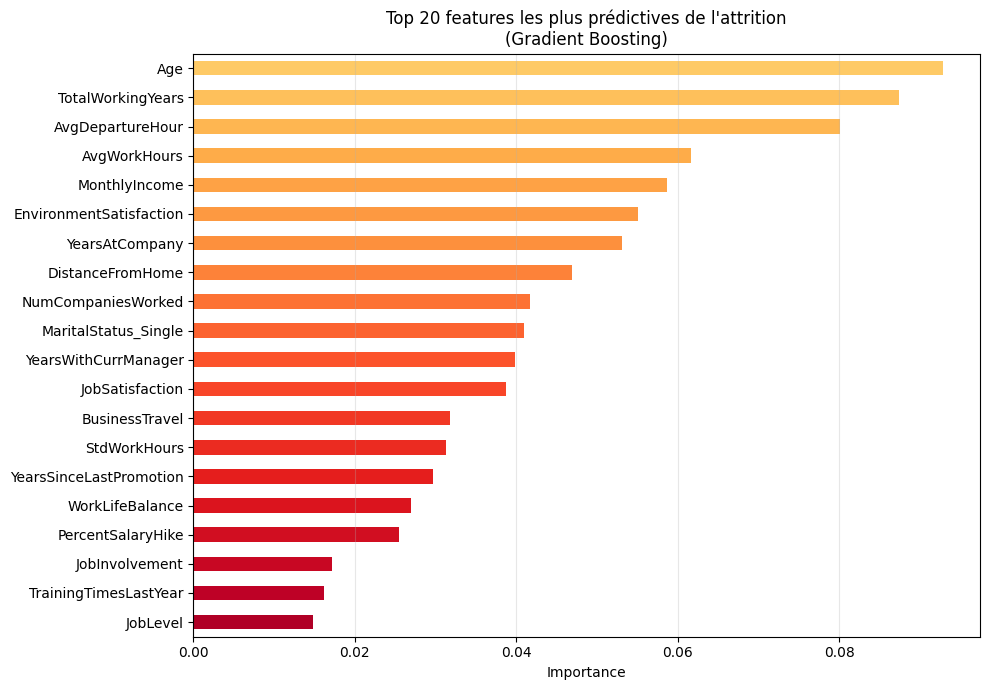

In [63]:
# ─── Feature importance — Gradient Boosting ───────────────────────────────────
feat_imp_gb = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp_gb.head(top_n).plot(
    kind='barh', ax=ax,
    color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, top_n))
)
ax.invert_yaxis()
ax.set_title(f"Top {top_n} features les plus prédictives de l'attrition\n(Gradient Boosting)")
ax.set_xlabel("Importance")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Analyse du seuil de décision

Par défaut, le modèle utilise un seuil de **0.5** pour classer un employé "à risque". Selon le contexte RH, on peut vouloir :
- **Seuil bas (ex: 0.3)** → détecter plus d'employés à risque (plus de rappel, moins de précision) — utile si le coût de rater une démission est élevé
- **Seuil haut (ex: 0.7)** → être plus sûr avant d'agir (plus de précision, moins de rappel) — utile si les actions de rétention sont coûteuses

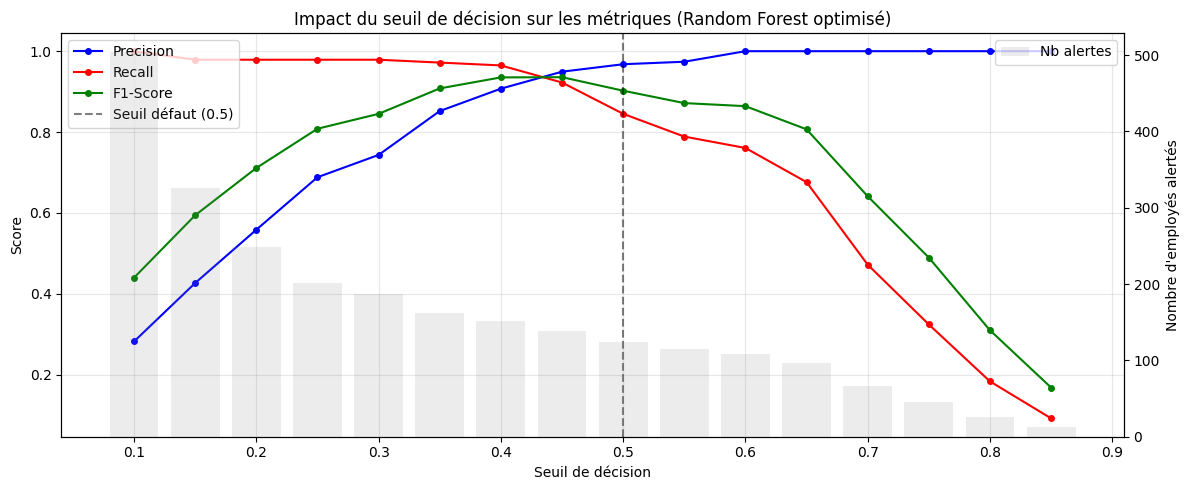


✓ Seuil optimal (F1 max) : 0.45
  Precision : 0.949 | Recall : 0.923 | F1 : 0.936
  Nombre d'employés alertés : 138


In [64]:
# ─── Impact du seuil sur les métriques ────────────────────────────────────────
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    threshold_results.append({
        "Seuil":     t,
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_t),
        "F1":        f1_score(y_test, y_pred_t, zero_division=0),
        "N_alertes": y_pred_t.sum()
    })

thr_df = pd.DataFrame(threshold_results)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(thr_df["Seuil"], thr_df["Precision"], 'b-o', markersize=4, label="Precision")
ax1.plot(thr_df["Seuil"], thr_df["Recall"],    'r-o', markersize=4, label="Recall")
ax1.plot(thr_df["Seuil"], thr_df["F1"],        'g-o', markersize=4, label="F1-Score")
ax1.axvline(0.5, color='k', linestyle='--', alpha=0.5, label="Seuil défaut (0.5)")
ax2.bar(thr_df["Seuil"], thr_df["N_alertes"], alpha=0.15, color='gray', width=0.04, label="Nb alertes")

ax1.set_xlabel("Seuil de décision")
ax1.set_ylabel("Score")
ax2.set_ylabel("Nombre d'employés alertés")
ax1.set_title("Impact du seuil de décision sur les métriques (Random Forest optimisé)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seuil optimal selon F1
best_t = thr_df.loc[thr_df["F1"].idxmax()]
print(f"\n✓ Seuil optimal (F1 max) : {best_t['Seuil']:.2f}")
print(f"  Precision : {best_t['Precision']:.3f} | Recall : {best_t['Recall']:.3f} | F1 : {best_t['F1']:.3f}")
print(f"  Nombre d'employés alertés : {int(best_t['N_alertes'])}")

## 11. Prédiction sur de nouveaux employés

Exemple d'utilisation du modèle en production : **scorer un employé** et obtenir sa probabilité d'attrition.

In [66]:
# ─── Scoring d'un sous-ensemble du test ────────────────────────────────────────
# (simule la prédiction sur de nouveaux employés)

sample = X_test.head(10).copy()
sample["Probabilité_Attrition"] = best_rf.predict_proba(sample)[:, 1].round(3)
sample["Attrition_Réelle"]      = y_test.head(10).values
sample["Attrition_Prédite"]     = best_rf.predict(X_test.head(10))
sample["Risque"] = sample["Probabilité_Attrition"].apply(
    lambda p: "Élevé" if p >= 0.6 else ("Moyen" if p >= 0.35 else "Faible")
)

print("Scoring de 10 employés du test set :")
print(sample[["Probabilité_Attrition", "Risque", "Attrition_Réelle", "Attrition_Prédite"]].to_string())

Scoring de 10 employés du test set :
      Probabilité_Attrition  Risque  Attrition_Réelle  Attrition_Prédite
3331                  0.077  Faible                 0                  0
2050                  0.428   Moyen                 1                  0
1213                  0.068  Faible                 0                  0
2355                  0.134  Faible                 0                  0
2433                  0.050  Faible                 0                  0
2626                  0.163  Faible                 0                  0
3519                  0.084  Faible                 0                  0
398                   0.810   Élevé                 1                  1
3763                  0.174  Faible                 0                  0
3193                  0.209  Faible                 0                  0


## Modele à ajouter : 
#### regression logistique
#### Le perceptron